<a href="https://colab.research.google.com/github/OJB-Quantum/Monte-Carlo-Sim/blob/main/GPU_Monte_Carlo_Inflation_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2025)

Open Access (CC-BY-4.0)

A Monte Carlo (MC) simulation provides a comprehensive exploration by modeling thousands of potential economic trajectories based on probabilistic distributions rather than static inputs. By leveraging a Graphics Processing Unit (GPU) via the Compute Unified Device Architecture (CUDA) platform, we can execute these massive computational arrays with extraordinary efficiency.

### Primer on Stochastic Economic Modeling and GPU Acceleration

In reality, productivity growth fluctuates annually due to technological breakthroughs, macroeconomic shocks, and demographic shifts. A Monte Carlo approach captures this volatility. Instead of assuming a constant annual growth rate, we sample growth rates from a normal probability distribution for each simulated year.

Because we are calculating distinct temporal paths across thousands of parallel universes, the computational burden scales exponentially. Traditional Central Processing Unit (CPU) arrays process these sequentially (or with limited threading). Conversely, a GPU architecture processes thousands of matrix operations simultaneously. Using the CuPy library (a GPU accelerated equivalent to NumPy), we can compute millions of data points in fractions of a second.

The following table explicitly defines the parameters and distributions utilized in this stochastic model:

| Symbol / Acronym | Definition |
| --- | --- |
| MC | Monte Carlo (A computational algorithm relying on repeated random sampling) |
| GPU | Graphics Processing Unit (Hardware optimized for parallel operations) |
| CUDA | Compute Unified Device Architecture (NVIDIA parallel computing platform) |
| $\mu$ | Mean (average) expected annual growth rate |
| $\sigma$ | Standard deviation (historical volatility of the growth rate) |
| $\mathcal{N}(\mu, \sigma^{2})$ | Normal probability distribution with a specified mean and variance |
| $g_{t}$ | Stochastic growth rate at time $t$, where $g_{t} \sim \mathcal{N}(\mu, \sigma^{2})$ |

### Environment Initialization

To execute this computational model within a Google Colab environment equipped with a hardware accelerator, ensure the requisite libraries are installed. We will utilize the `uv` package manager for rapid resolution.

```bash
!uv pip install cupy-cuda12x matplotlib numpy

```

*(Note: Select the appropriate `cupy` version corresponding to your specific Colab CUDA environment if 12.x is unavailable).*

### Python Implementation: GPU Accelerated Simulation

The following script adheres strictly to PEP 8 and PEP 257 standards. It initializes a massive, parallelized matrix operation to simulate ten thousand distinct economic realities simultaneously.

Simulated 10,000 trajectories across 30 years in 2.007 seconds.

Final-year summary after 30 years (5th, median, 95th percentiles)
----------------------------------------------------------------------------------------
Metric                                Lower       Median        Upper      Median CAGR
----------------------------------------------------------------------------------------
Technology prices                    173.14       181.00       189.47            2.00%
Service prices                       749.13       891.59      1060.18            7.57%
Aggregate prices                     453.69       510.08       573.88            5.58%
Service/technology price             416.41       492.67       580.98            5.46%
----------------------------------------------------------------------------------------
Probability that cumulative service inflation exceeds technology inflation: 100.00%


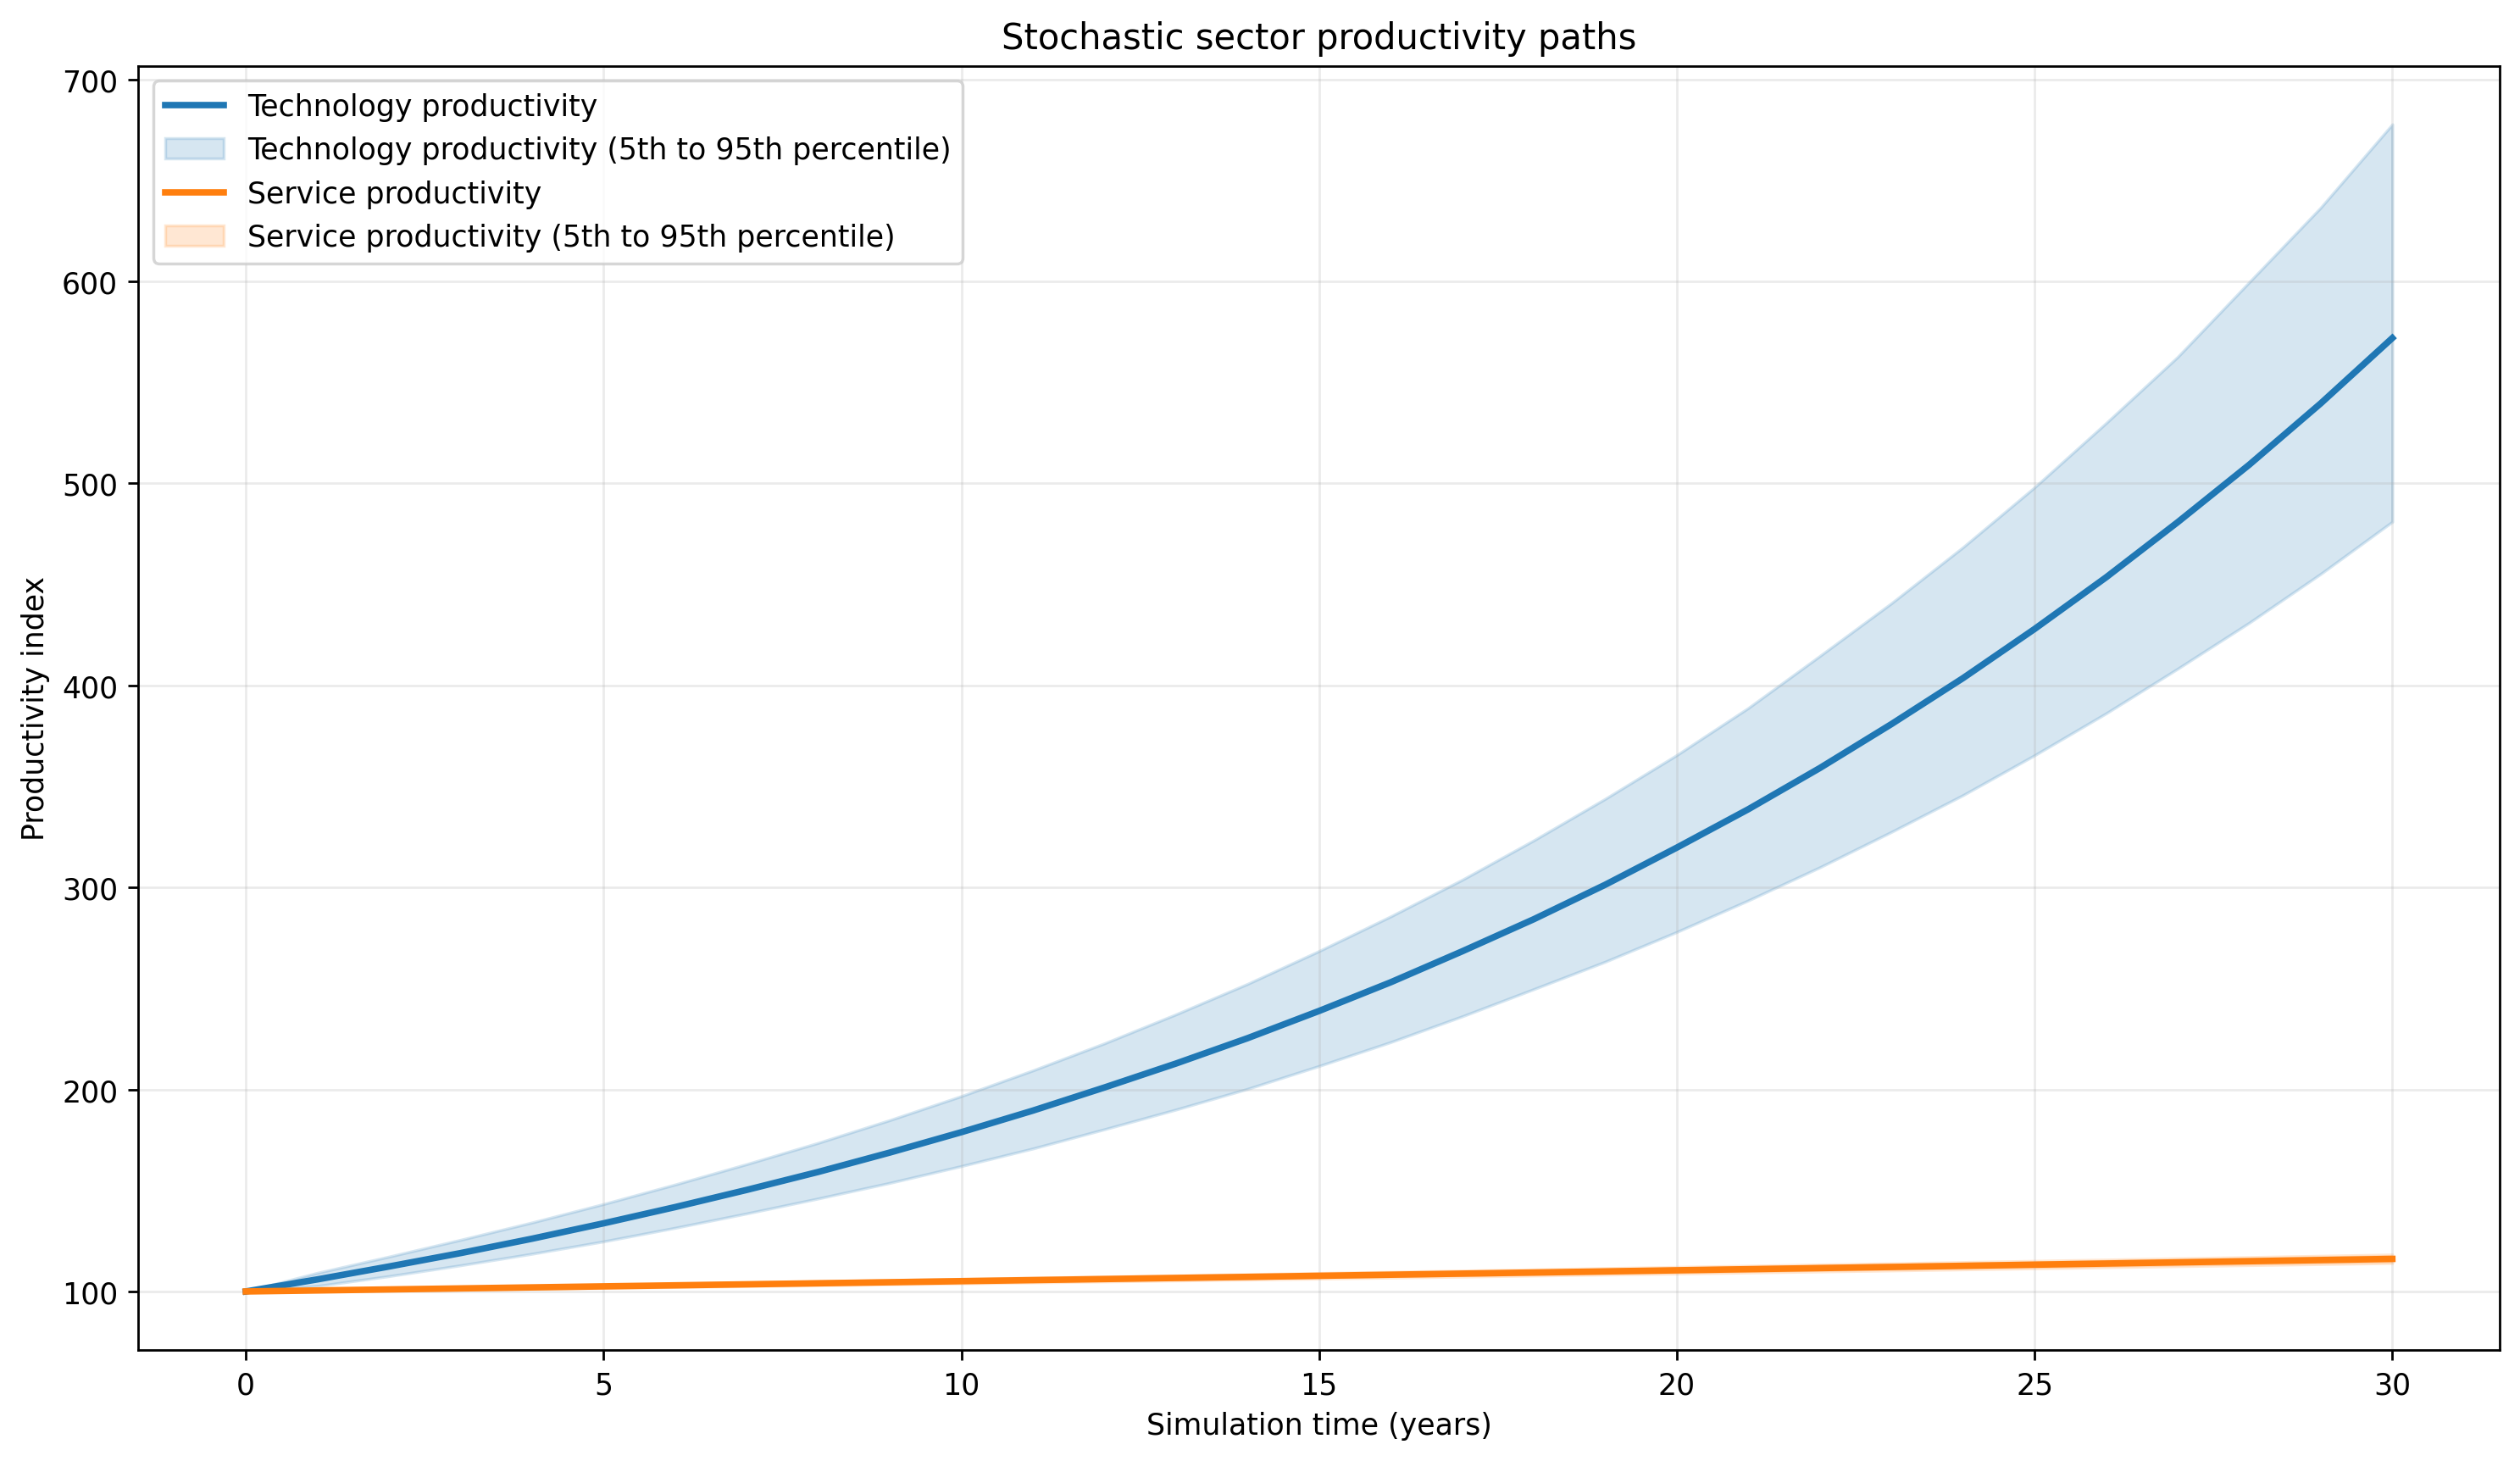

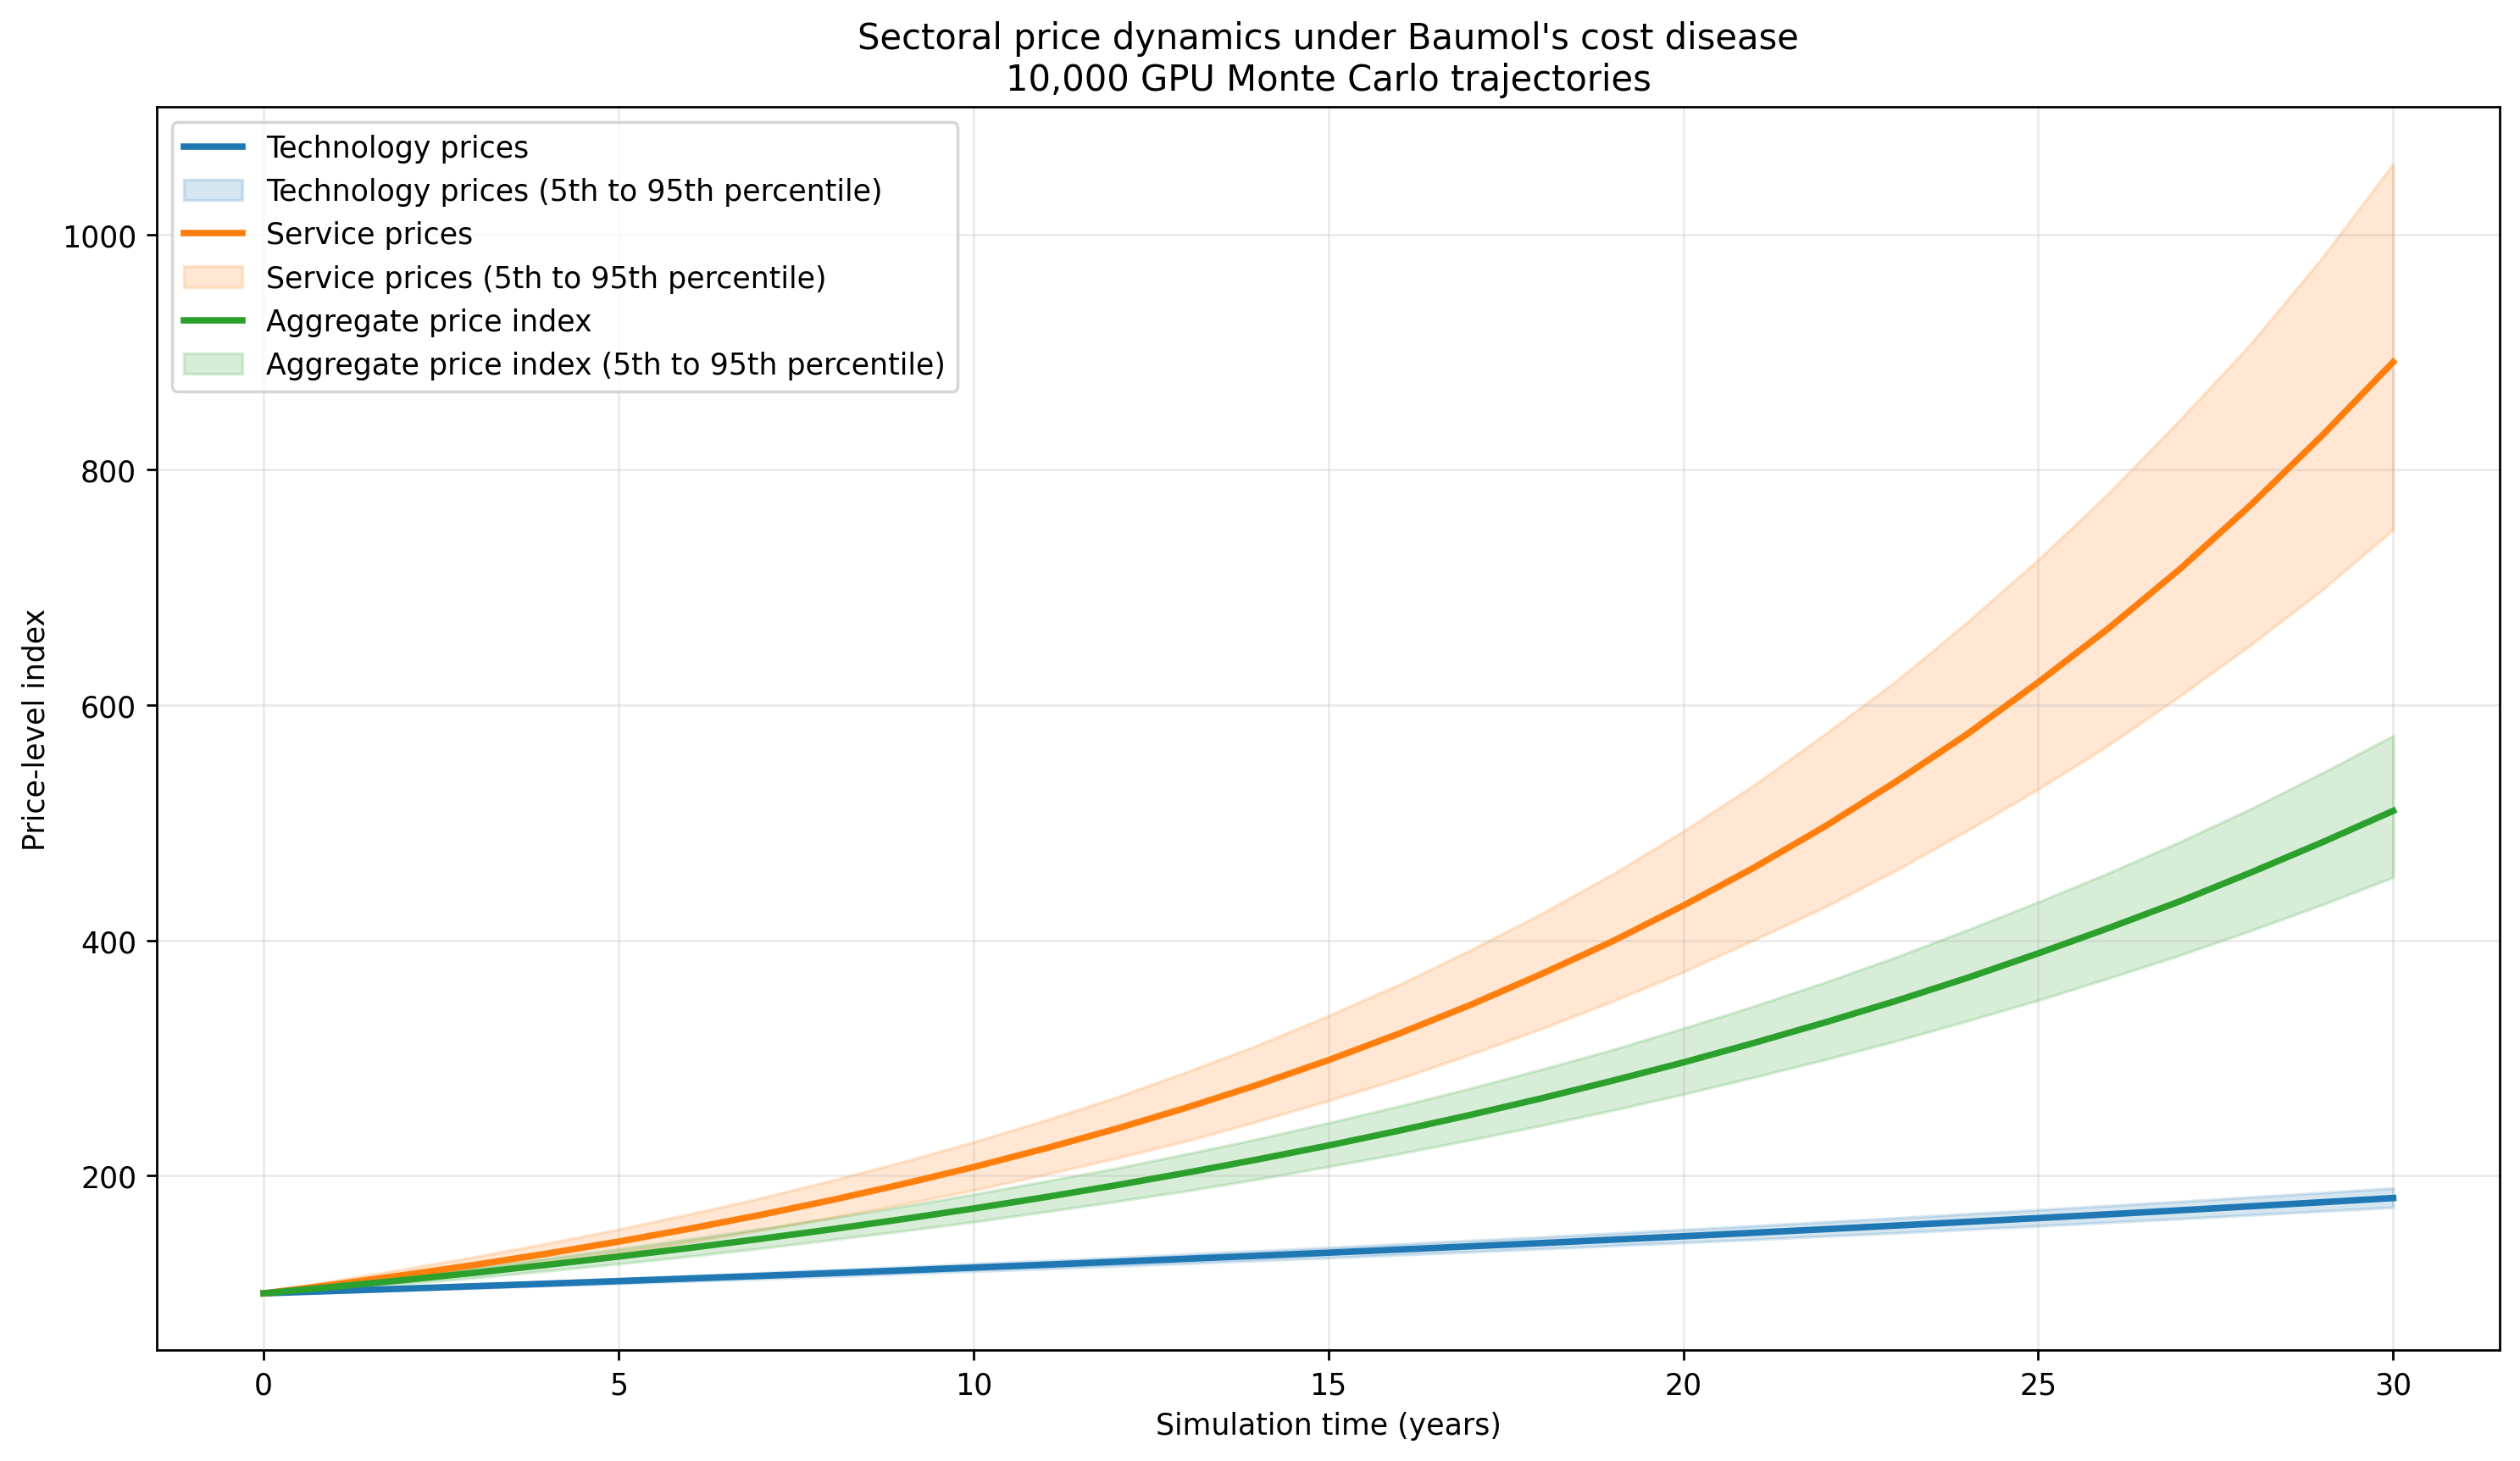

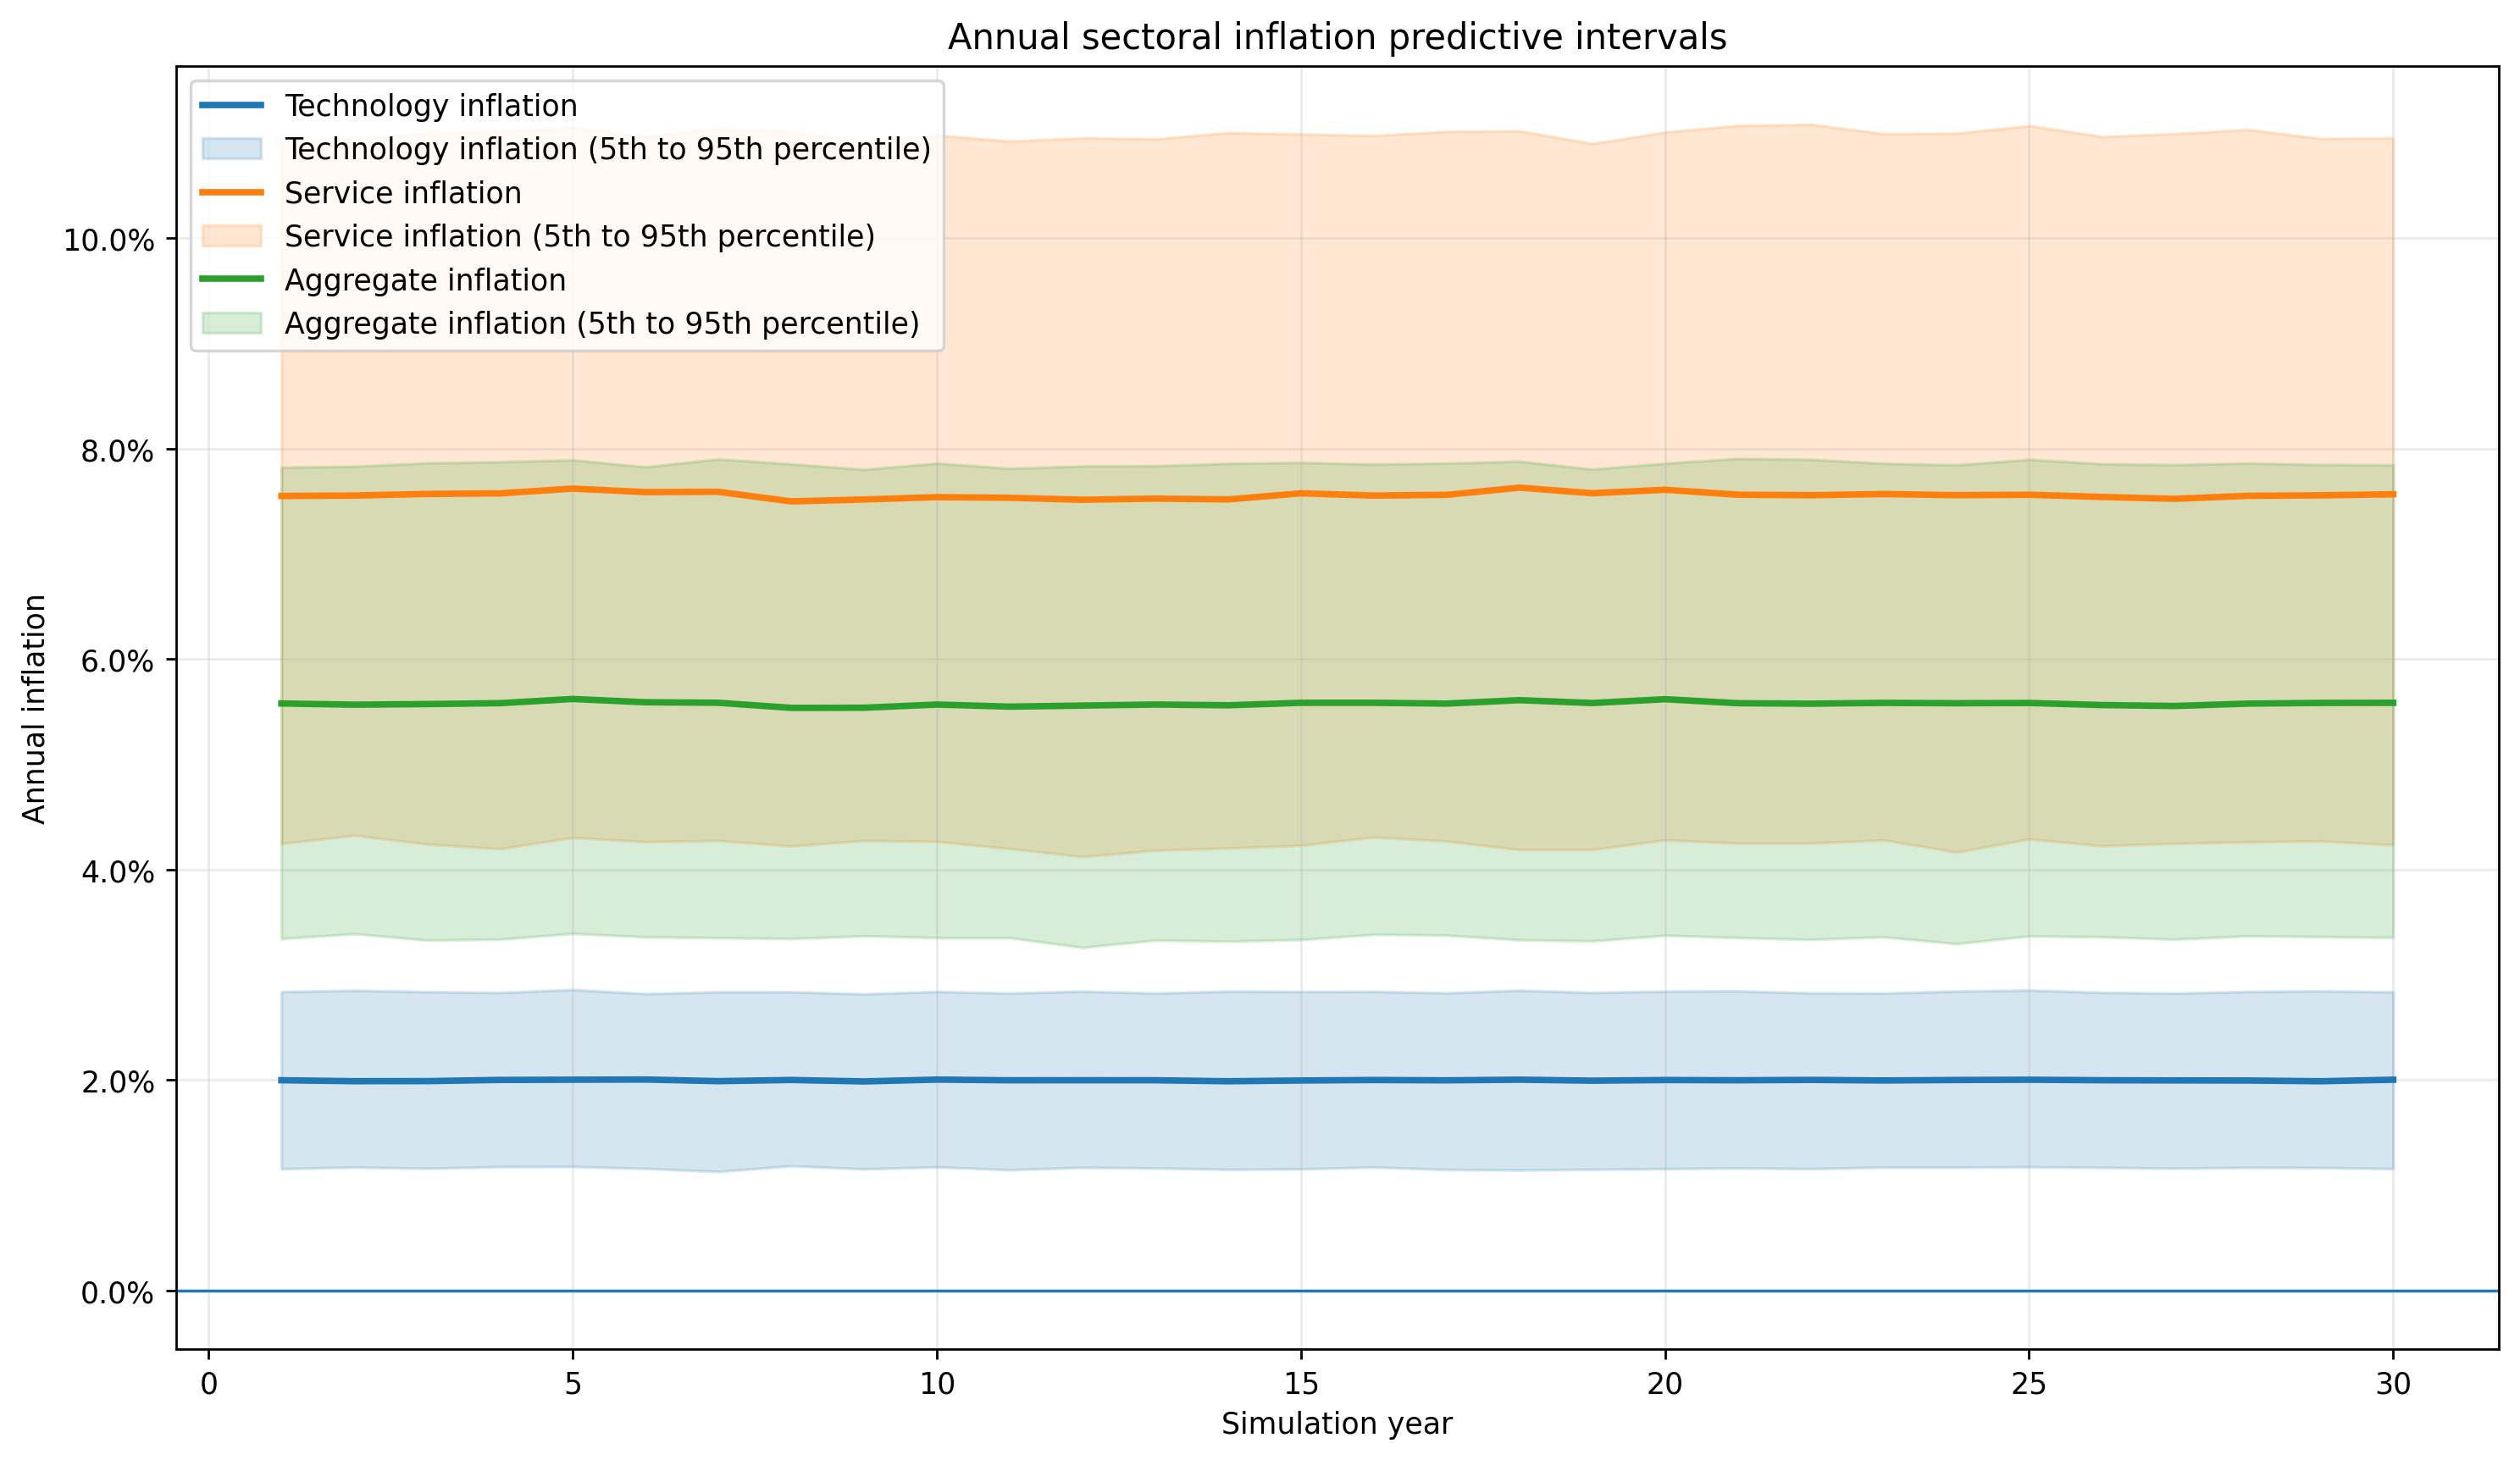

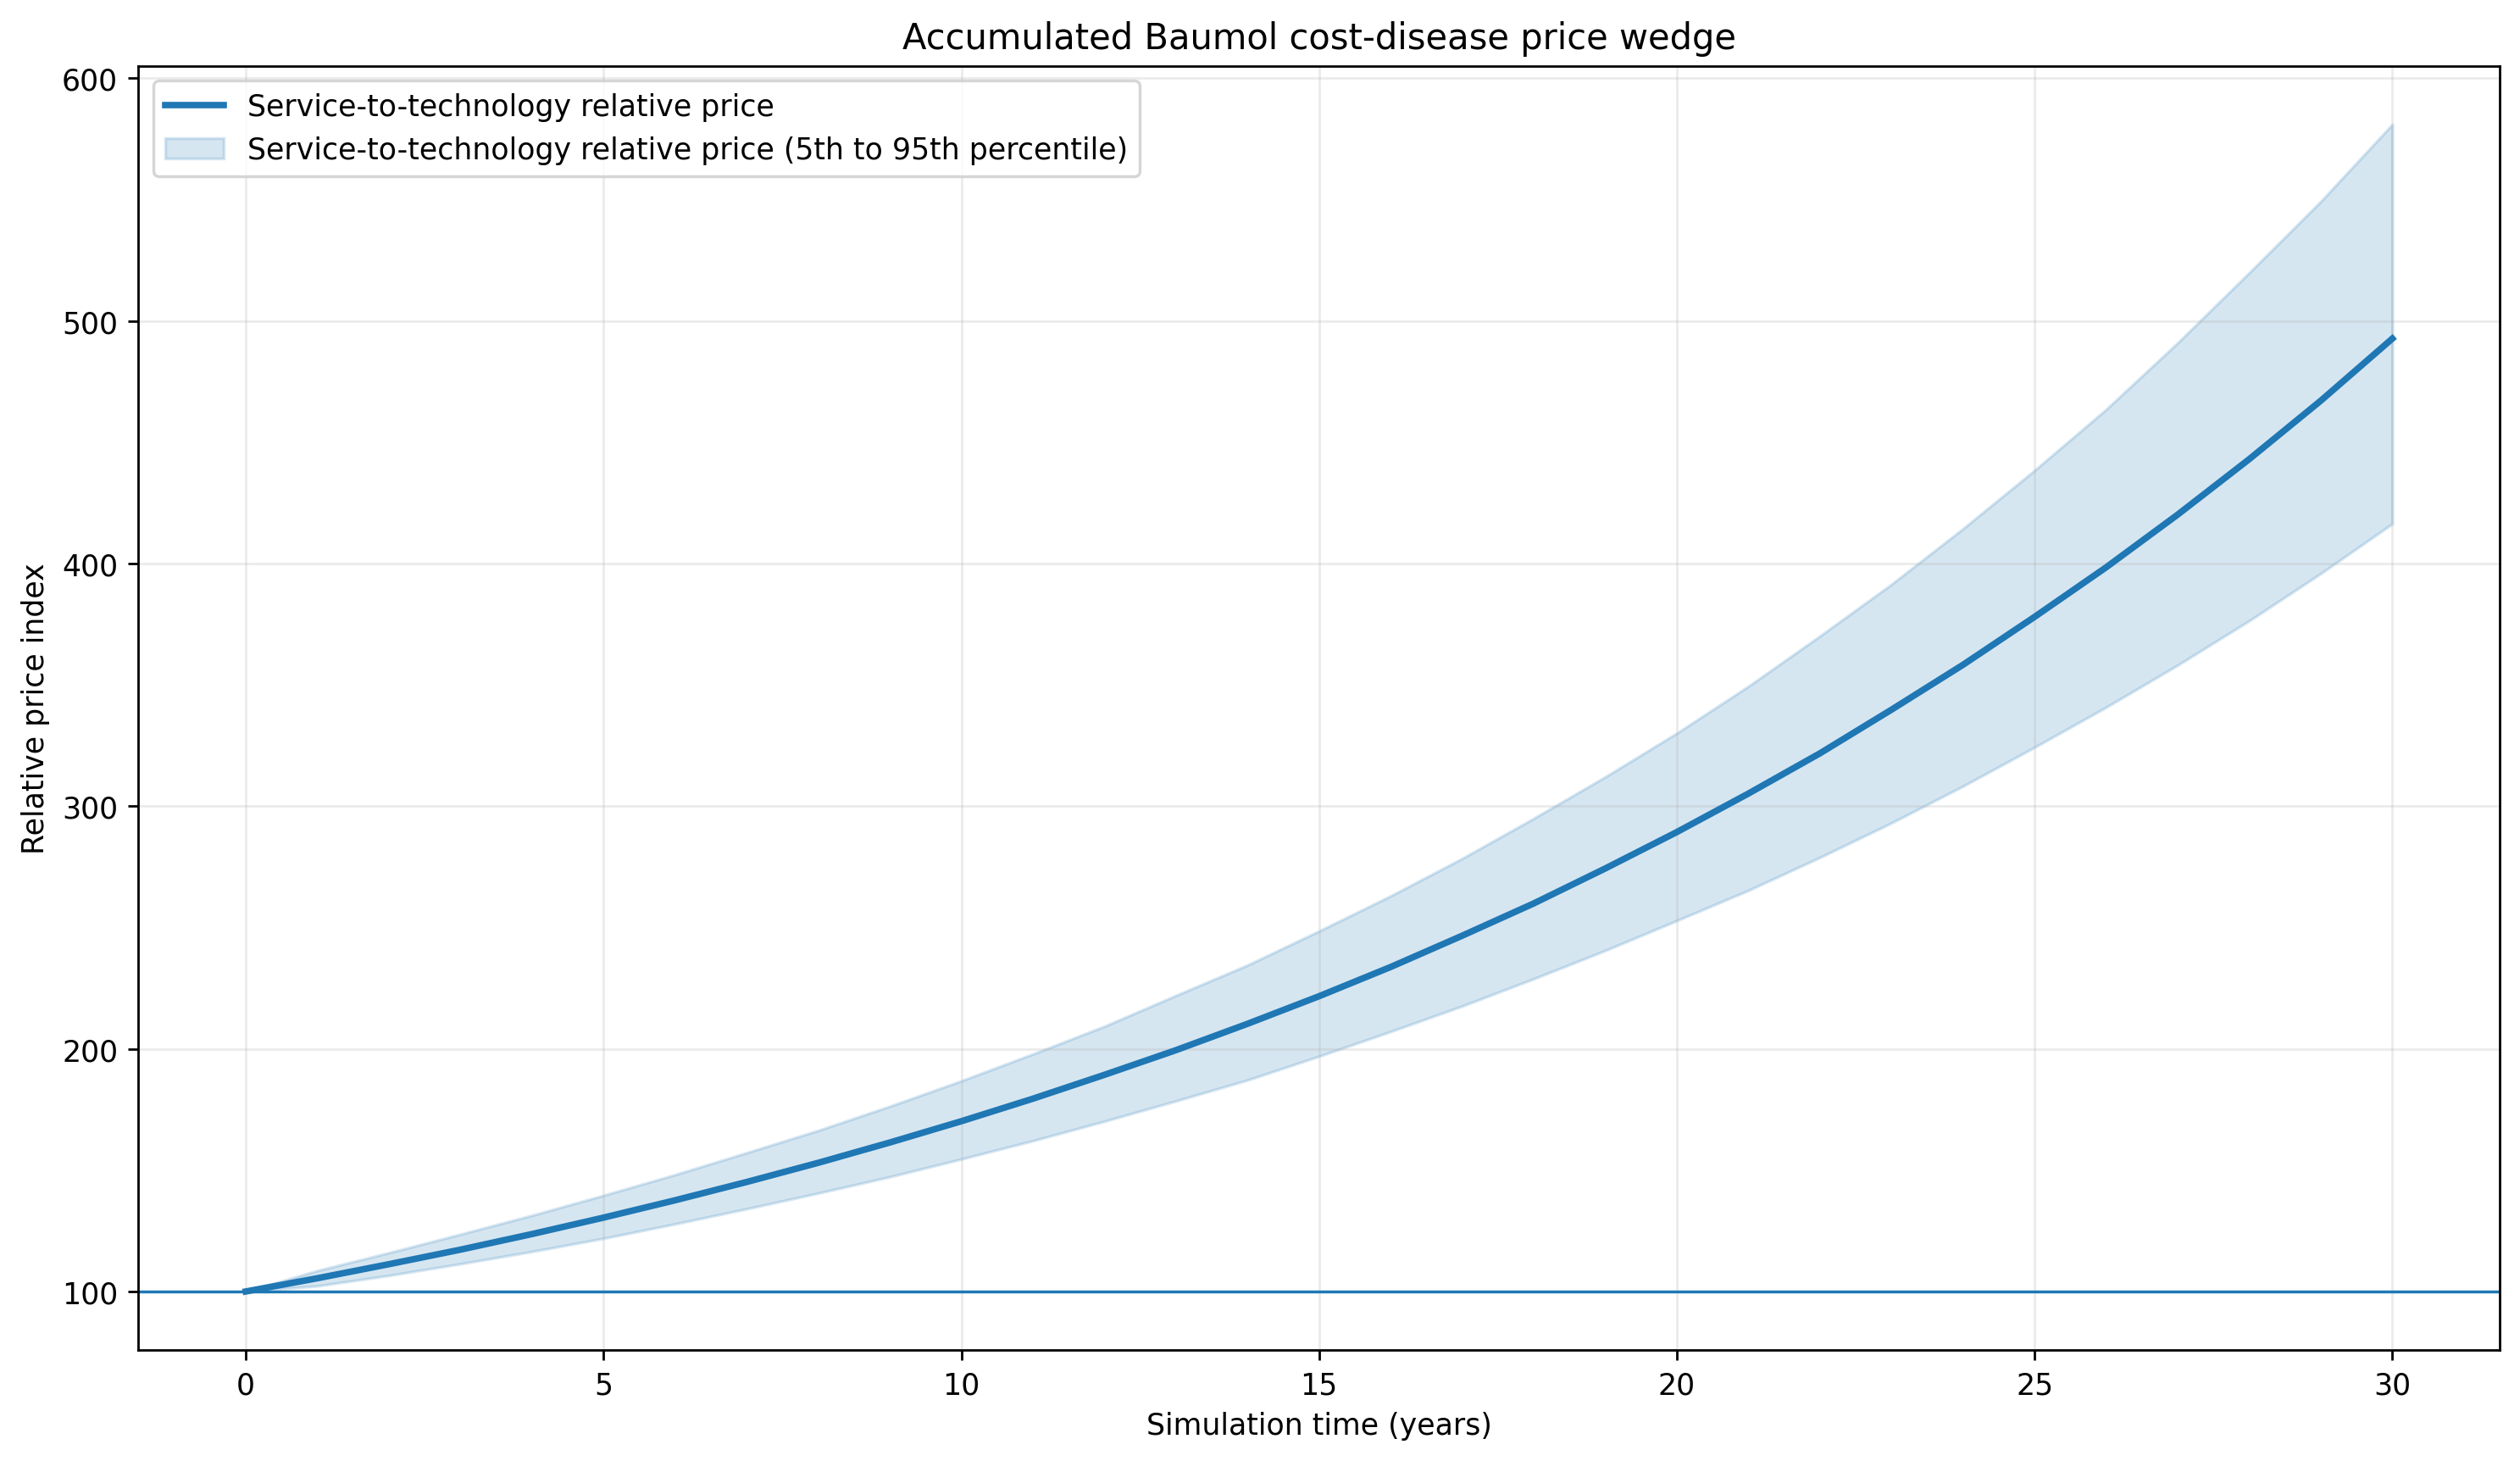

In [1]:
"""Simulate sectoral inflation under Baumol's cost disease on a GPU.

The model draws correlated stochastic productivity growth for a technology
sector and a service sector. Economy-wide wages track technology-sector
productivity, an exogenous inflation anchor, and a common wage disturbance.
Sector prices follow unit labor costs,

    P[i, t] / P[i, 0] = (W[t] / W[0]) / (A[i, t] / A[i, 0]).

A fixed-share geometric price index summarizes the aggregate price level.
CuPy performs simulation and percentile calculations on the GPU. Matplotlib
receives only reduced NumPy arrays for rendering.
"""

from __future__ import annotations

import dataclasses
import math
import time

import cupy as cp
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.axes import Axes
from matplotlib.ticker import PercentFormatter

# =============================================================================
# CONTROL KNOBS
# =============================================================================
NUM_SIMULATIONS: int = 10_000
SIMULATION_YEARS: int = 30
INITIAL_INDEX_VALUE: float = 100.0
RANDOM_SEED: int = 20260712

# Arithmetic annual productivity-growth moments.
TECH_MEAN_PRODUCTIVITY_GROWTH: float = 0.060
TECH_PRODUCTIVITY_GROWTH_STD: float = 0.020
SERVICE_MEAN_PRODUCTIVITY_GROWTH: float = 0.005
SERVICE_PRODUCTIVITY_GROWTH_STD: float = 0.002

# Correlation between latent annual log-productivity innovations.
PRODUCTIVITY_SHOCK_CORRELATION: float = 0.25

# Nominal anchor and common multiplicative wage disturbance.
ECONOMY_WIDE_INFLATION_RATE: float = 0.020
WAGE_LOG_SHOCK_STD: float = 0.005

# Fixed expenditure shares for the geometric aggregate price index.
TECH_EXPENDITURE_SHARE: float = 0.35

# Monte Carlo predictive interval.
LOWER_PERCENTILE: float = 5.0
UPPER_PERCENTILE: float = 95.0

# Visualization.
FIGURE_DPI: int = 250
FIGURE_SIZE: tuple[float, float] = (12.0, 7.0)
FAN_ALPHA: float = 0.18
# =============================================================================


@dataclasses.dataclass(frozen=True)
class SimulationConfig:
    """Stores validated model and visualization parameters."""

    num_simulations: int
    simulation_years: int
    initial_index_value: float
    random_seed: int
    tech_mean_growth: float
    tech_growth_std: float
    service_mean_growth: float
    service_growth_std: float
    productivity_correlation: float
    economy_wide_inflation_rate: float
    wage_log_shock_std: float
    tech_expenditure_share: float
    lower_percentile: float
    upper_percentile: float


@dataclasses.dataclass(frozen=True)
class SimulationResults:
    """Contains simulated indices stored in GPU memory."""

    years: cp.ndarray
    tech_productivity: cp.ndarray
    service_productivity: cp.ndarray
    wages: cp.ndarray
    tech_prices: cp.ndarray
    service_prices: cp.ndarray
    aggregate_prices: cp.ndarray


def build_default_config() -> SimulationConfig:
    """Builds a simulation configuration from the control knobs.

    Returns:
        A populated simulation configuration.
    """
    return SimulationConfig(
        num_simulations=NUM_SIMULATIONS,
        simulation_years=SIMULATION_YEARS,
        initial_index_value=INITIAL_INDEX_VALUE,
        random_seed=RANDOM_SEED,
        tech_mean_growth=TECH_MEAN_PRODUCTIVITY_GROWTH,
        tech_growth_std=TECH_PRODUCTIVITY_GROWTH_STD,
        service_mean_growth=SERVICE_MEAN_PRODUCTIVITY_GROWTH,
        service_growth_std=SERVICE_PRODUCTIVITY_GROWTH_STD,
        productivity_correlation=PRODUCTIVITY_SHOCK_CORRELATION,
        economy_wide_inflation_rate=ECONOMY_WIDE_INFLATION_RATE,
        wage_log_shock_std=WAGE_LOG_SHOCK_STD,
        tech_expenditure_share=TECH_EXPENDITURE_SHARE,
        lower_percentile=LOWER_PERCENTILE,
        upper_percentile=UPPER_PERCENTILE,
    )


def validate_config(config: SimulationConfig) -> None:
    """Validates simulation parameters.

    Args:
        config: Model and simulation parameters.

    Raises:
        ValueError: A parameter lies outside its valid domain.
    """
    if config.num_simulations <= 0:
        raise ValueError("num_simulations must be positive.")
    if config.simulation_years <= 0:
        raise ValueError("simulation_years must be positive.")
    if config.initial_index_value <= 0.0:
        raise ValueError("initial_index_value must be positive.")

    growth_means = (
        config.tech_mean_growth,
        config.service_mean_growth,
    )
    if any(mean <= -1.0 for mean in growth_means):
        raise ValueError("Mean growth rates must exceed -1.0.")

    growth_standard_deviations = (
        config.tech_growth_std,
        config.service_growth_std,
        config.wage_log_shock_std,
    )
    if any(std < 0.0 for std in growth_standard_deviations):
        raise ValueError("Growth standard deviations cannot be negative.")

    if not -1.0 <= config.productivity_correlation <= 1.0:
        raise ValueError("productivity_correlation must lie in [-1, 1].")
    if config.economy_wide_inflation_rate <= -1.0:
        raise ValueError("economy_wide_inflation_rate must exceed -1.0.")
    if not 0.0 <= config.tech_expenditure_share <= 1.0:
        raise ValueError("tech_expenditure_share must lie in [0, 1].")
    if not 0.0 <= config.lower_percentile < 50.0:
        raise ValueError("lower_percentile must lie in [0, 50).")
    if not 50.0 < config.upper_percentile <= 100.0:
        raise ValueError("upper_percentile must lie in (50, 100].")


def _lognormal_parameters(
    arithmetic_mean_growth: float,
    arithmetic_growth_std: float,
) -> tuple[float, float]:
    """Converts gross-growth moments to lognormal parameters.

    The supplied mean and standard deviation describe the arithmetic annual
    growth rate. The returned values parameterize the logarithm of the gross
    growth factor, which guarantees a positive productivity level.

    Args:
        arithmetic_mean_growth: Expected annual arithmetic growth rate.
        arithmetic_growth_std: Standard deviation of annual arithmetic growth.

    Returns:
        The mean and standard deviation of the log gross-growth factor.
    """
    mean_gross_factor = 1.0 + arithmetic_mean_growth
    variance_ratio = (arithmetic_growth_std / mean_gross_factor) ** 2
    log_variance = math.log1p(variance_ratio)
    log_standard_deviation = math.sqrt(log_variance)
    log_mean = math.log(mean_gross_factor) - 0.5 * log_variance
    return log_mean, log_standard_deviation


def _prepend_zero_column(values: cp.ndarray) -> cp.ndarray:
    """Prepends a zero-valued initial-period column to a two-dimensional array.

    Args:
        values: Array with shape ``(num_simulations, simulation_years)``.

    Returns:
        An array with one additional leading column.
    """
    zero_column = cp.zeros((values.shape[0], 1), dtype=values.dtype)
    return cp.concatenate((zero_column, values), axis=1)


def simulate_sectoral_inflation(
    config: SimulationConfig,
) -> SimulationResults:
    """Runs the GPU-accelerated Monte Carlo simulation.

    The productivity factors follow correlated lognormal processes whose
    arithmetic growth moments match the control knobs. The correlation knob
    applies to the latent Gaussian log innovations. Wages respond to
    technology productivity, the common inflation anchor, and a mean-one
    multiplicative wage shock.

    Args:
        config: Validated simulation parameters.

    Returns:
        Simulated productivity, wage, and price indices in GPU memory.
    """
    validate_config(config)
    random_state = cp.random.RandomState(config.random_seed)
    shape = (config.num_simulations, config.simulation_years)

    tech_log_mean, tech_log_std = _lognormal_parameters(
        config.tech_mean_growth,
        config.tech_growth_std,
    )
    service_log_mean, service_log_std = _lognormal_parameters(
        config.service_mean_growth,
        config.service_growth_std,
    )

    tech_standard_normal = random_state.standard_normal(size=shape)
    independent_standard_normal = random_state.standard_normal(size=shape)
    correlation_scale = math.sqrt(max(0.0, 1.0 - config.productivity_correlation**2))
    service_standard_normal = (
        config.productivity_correlation * tech_standard_normal
        + correlation_scale * independent_standard_normal
    )

    tech_log_growth = tech_log_mean + tech_log_std * tech_standard_normal
    service_log_growth = service_log_mean + service_log_std * service_standard_normal

    wage_shock_mean = -0.5 * config.wage_log_shock_std**2
    wage_log_shock = random_state.normal(
        loc=wage_shock_mean,
        scale=config.wage_log_shock_std,
        size=shape,
    )
    common_inflation_log_growth = math.log1p(config.economy_wide_inflation_rate)
    wage_log_growth = tech_log_growth + common_inflation_log_growth + wage_log_shock

    cumulative_tech_log_growth = _prepend_zero_column(
        cp.cumsum(tech_log_growth, axis=1)
    )
    cumulative_service_log_growth = _prepend_zero_column(
        cp.cumsum(service_log_growth, axis=1)
    )
    cumulative_wage_log_growth = _prepend_zero_column(
        cp.cumsum(wage_log_growth, axis=1)
    )

    initial_value = config.initial_index_value
    tech_productivity = initial_value * cp.exp(cumulative_tech_log_growth)
    service_productivity = initial_value * cp.exp(cumulative_service_log_growth)
    wages = initial_value * cp.exp(cumulative_wage_log_growth)

    tech_log_price_change = cumulative_wage_log_growth - cumulative_tech_log_growth
    service_log_price_change = (
        cumulative_wage_log_growth - cumulative_service_log_growth
    )
    tech_prices = initial_value * cp.exp(tech_log_price_change)
    service_prices = initial_value * cp.exp(service_log_price_change)

    service_expenditure_share = 1.0 - config.tech_expenditure_share
    aggregate_log_price_change = (
        config.tech_expenditure_share * tech_log_price_change
        + service_expenditure_share * service_log_price_change
    )
    aggregate_prices = initial_value * cp.exp(aggregate_log_price_change)

    years = cp.arange(config.simulation_years + 1, dtype=cp.int32)
    return SimulationResults(
        years=years,
        tech_productivity=tech_productivity,
        service_productivity=service_productivity,
        wages=wages,
        tech_prices=tech_prices,
        service_prices=service_prices,
        aggregate_prices=aggregate_prices,
    )


def _predictive_band(
    values: cp.ndarray,
    config: SimulationConfig,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Calculates a median and predictive interval on the GPU.

    Args:
        values: Simulation array with trajectories along axis zero.
        config: Configuration containing percentile bounds.

    Returns:
        Lower, median, and upper trajectories as NumPy arrays.
    """
    percentiles = cp.percentile(
        values,
        q=(config.lower_percentile, 50.0, config.upper_percentile),
        axis=0,
    )
    percentiles_cpu = cp.asnumpy(percentiles)
    return (
        percentiles_cpu[0],
        percentiles_cpu[1],
        percentiles_cpu[2],
    )


def _annual_inflation_percent(price_levels: cp.ndarray) -> cp.ndarray:
    """Calculates annual continuously chained inflation rates in percent.

    Args:
        price_levels: Positive price indices with time along axis one.

    Returns:
        Annual arithmetic inflation rates in percent.
    """
    log_changes = cp.diff(cp.log(price_levels), axis=1)
    return 100.0 * cp.expm1(log_changes)


def _plot_fan_series(
    axes: Axes,
    years: np.ndarray,
    values: cp.ndarray,
    label: str,
    config: SimulationConfig,
) -> None:
    """Plots a median trajectory and its predictive interval.

    Args:
        axes: Matplotlib axes that receive the series.
        years: CPU-resident horizontal coordinates.
        values: GPU-resident simulation trajectories.
        label: Legend label for the median trajectory.
        config: Configuration containing predictive interval bounds.
    """
    lower, median, upper = _predictive_band(values, config)
    line = axes.plot(years, median, linewidth=2.2, label=label)[0]
    interval_label = (
        f"{label} ({config.lower_percentile:.0f}th to "
        f"{config.upper_percentile:.0f}th percentile)"
    )
    axes.fill_between(
        years,
        lower,
        upper,
        color=line.get_color(),
        alpha=FAN_ALPHA,
        label=interval_label,
    )


def configure_matplotlib() -> None:
    """Applies the visualization control knobs."""
    plt.rcParams.update(
        {
            "figure.dpi": FIGURE_DPI,
            "figure.figsize": FIGURE_SIZE,
            "axes.grid": True,
            "grid.alpha": 0.25,
        }
    )


def plot_productivity_indices(
    results: SimulationResults,
    config: SimulationConfig,
) -> None:
    """Renders stochastic sector productivity indices.

    Args:
        results: GPU-resident simulation output.
        config: Model and visualization parameters.
    """
    years = cp.asnumpy(results.years)
    figure, axes = plt.subplots()
    _plot_fan_series(
        axes,
        years,
        results.tech_productivity,
        "Technology productivity",
        config,
    )
    _plot_fan_series(
        axes,
        years,
        results.service_productivity,
        "Service productivity",
        config,
    )
    axes.set_xlabel("Simulation time (years)")
    axes.set_ylabel("Productivity index")
    axes.set_title("Stochastic sector productivity paths")
    axes.legend(loc="upper left", frameon=True)
    figure.tight_layout()
    plt.show()
    plt.close(figure)


def plot_price_indices(
    results: SimulationResults,
    config: SimulationConfig,
) -> None:
    """Renders sector and aggregate price-level predictive intervals.

    Args:
        results: GPU-resident simulation output.
        config: Model and visualization parameters.
    """
    years = cp.asnumpy(results.years)
    figure, axes = plt.subplots()
    _plot_fan_series(
        axes,
        years,
        results.tech_prices,
        "Technology prices",
        config,
    )
    _plot_fan_series(
        axes,
        years,
        results.service_prices,
        "Service prices",
        config,
    )
    _plot_fan_series(
        axes,
        years,
        results.aggregate_prices,
        "Aggregate price index",
        config,
    )
    axes.set_xlabel("Simulation time (years)")
    axes.set_ylabel("Price-level index")
    axes.set_title(
        "Sectoral price dynamics under Baumol's cost disease\n"
        f"{config.num_simulations:,} GPU Monte Carlo trajectories"
    )
    axes.legend(loc="upper left", frameon=True)
    figure.tight_layout()
    plt.show()
    plt.close(figure)


def plot_annual_inflation(
    results: SimulationResults,
    config: SimulationConfig,
) -> None:
    """Renders annual sector and aggregate inflation distributions.

    Args:
        results: GPU-resident simulation output.
        config: Model and visualization parameters.
    """
    years = cp.asnumpy(results.years[1:])
    tech_inflation = _annual_inflation_percent(results.tech_prices)
    service_inflation = _annual_inflation_percent(results.service_prices)
    aggregate_inflation = _annual_inflation_percent(results.aggregate_prices)

    figure, axes = plt.subplots()
    _plot_fan_series(
        axes,
        years,
        tech_inflation,
        "Technology inflation",
        config,
    )
    _plot_fan_series(
        axes,
        years,
        service_inflation,
        "Service inflation",
        config,
    )
    _plot_fan_series(
        axes,
        years,
        aggregate_inflation,
        "Aggregate inflation",
        config,
    )
    axes.axhline(0.0, linewidth=1.0)
    axes.set_xlabel("Simulation year")
    axes.set_ylabel("Annual inflation")
    axes.yaxis.set_major_formatter(PercentFormatter(xmax=100.0))
    axes.set_title("Annual sectoral inflation predictive intervals")
    axes.legend(loc="upper left", frameon=True)
    figure.tight_layout()
    plt.show()
    plt.close(figure)


def plot_relative_service_price(
    results: SimulationResults,
    config: SimulationConfig,
) -> None:
    """Renders the service-to-technology relative price wedge.

    Args:
        results: GPU-resident simulation output.
        config: Model and visualization parameters.
    """
    years = cp.asnumpy(results.years)
    relative_service_price = (
        config.initial_index_value * results.service_prices / results.tech_prices
    )

    figure, axes = plt.subplots()
    _plot_fan_series(
        axes,
        years,
        relative_service_price,
        "Service-to-technology relative price",
        config,
    )
    axes.axhline(config.initial_index_value, linewidth=1.0)
    axes.set_xlabel("Simulation time (years)")
    axes.set_ylabel("Relative price index")
    axes.set_title("Accumulated Baumol cost-disease price wedge")
    axes.legend(loc="upper left", frameon=True)
    figure.tight_layout()
    plt.show()
    plt.close(figure)


def _terminal_statistics(
    values: cp.ndarray,
    config: SimulationConfig,
) -> tuple[float, float, float]:
    """Calculates terminal lower, median, and upper percentiles.

    Args:
        values: Simulated trajectories.
        config: Configuration containing percentile bounds.

    Returns:
        Terminal lower percentile, median, and upper percentile.
    """
    percentiles = cp.percentile(
        values[:, -1],
        q=(config.lower_percentile, 50.0, config.upper_percentile),
    )
    lower, median, upper = cp.asnumpy(percentiles)
    return float(lower), float(median), float(upper)


def print_terminal_summary(
    results: SimulationResults,
    config: SimulationConfig,
) -> None:
    """Prints final-year price statistics and implied median CAGRs.

    Args:
        results: GPU-resident simulation output.
        config: Model and simulation parameters.
    """
    relative_service_price = (
        config.initial_index_value * results.service_prices / results.tech_prices
    )
    series = (
        ("Technology prices", results.tech_prices),
        ("Service prices", results.service_prices),
        ("Aggregate prices", results.aggregate_prices),
        ("Service/technology price", relative_service_price),
    )

    print(
        f"\nFinal-year summary after {config.simulation_years} years "
        f"({config.lower_percentile:.0f}th, median, "
        f"{config.upper_percentile:.0f}th percentiles)"
    )
    print("-" * 88)
    print(
        f"{'Metric':<30} {'Lower':>12} {'Median':>12} {'Upper':>12} {'Median CAGR':>16}"
    )
    print("-" * 88)

    for label, values in series:
        lower, median, upper = _terminal_statistics(values, config)
        median_cagr = 100.0 * math.expm1(
            math.log(median / config.initial_index_value) / config.simulation_years
        )
        print(
            f"{label:<30} {lower:>12.2f} {median:>12.2f} "
            f"{upper:>12.2f} {median_cagr:>15.2f}%"
        )

    service_outpaces_tech = (
        100.0
        * cp.mean(results.service_prices[:, -1] > results.tech_prices[:, -1]).item()
    )
    print("-" * 88)
    print(
        "Probability that cumulative service inflation exceeds technology "
        f"inflation: {service_outpaces_tech:.2f}%"
    )


def main() -> None:
    """Runs the simulation, reports statistics, and renders all figures."""
    config = build_default_config()
    validate_config(config)
    configure_matplotlib()

    try:
        device_count = cp.cuda.runtime.getDeviceCount()
    except cp.cuda.runtime.CUDARuntimeError as error:
        raise RuntimeError(
            "CuPy could not access a CUDA-capable GPU. Install the CuPy "
            "package matching the active CUDA version and enable a GPU "
            "runtime."
        ) from error

    if device_count < 1:
        raise RuntimeError("No CUDA-capable GPU was detected.")

    start_time = time.perf_counter()
    results = simulate_sectoral_inflation(config)
    cp.cuda.Stream.null.synchronize()
    elapsed_seconds = time.perf_counter() - start_time

    print(
        f"Simulated {config.num_simulations:,} trajectories across "
        f"{config.simulation_years} years in {elapsed_seconds:.3f} seconds."
    )
    print_terminal_summary(results, config)
    plot_productivity_indices(results, config)
    plot_price_indices(results, config)
    plot_annual_inflation(results, config)
    plot_relative_service_price(results, config)


if __name__ == "__main__":
    main()

### Summary

Introducing a GPU accelerated Monte Carlo simulation makes the exploration vastly more comprehensive. By simulating thousands of stochastic trajectories simultaneously with CuPy, we reveal a critical insight. Even under extreme probabilistic volatility, the technological sector prices remain tightly bounded (due to internally offsetting productivity). Conversely, the service sector prices consistently exhibit aggressive, exponential escalation with heavily skewed upside risk, confirming that highly lucrative external sectors inherently generate profound localized inflation.